In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans

names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

In [2]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    

# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/25Util/4KB/90-10-LBA/5GB/clubbedWrites/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1e6  #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']


# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 3)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Data Written (Mbytes)')
plt.grid(True)  # Optionally, add grid lines
plt.title("5GB writes to DM-Hybrid, each write is 4KB. \n Zone is 25 \% full")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/25Util_4K_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Data written (GBs)')
plt.ylabel('BW (Mbytes)')
plt.grid(True)  # Optionally, add grid lines
plt.title("5GB writes to DM-Hybrid, each write is 4KB. \n Zone is 25 \% full")    
plt.savefig(f'/home/surbhi/github/surbhi-plots/new/STL/25Util_4K_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_144645/2774938598.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1861.74286586 1861.74286586]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[start:end-1] += write_rate_per_ms


In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/Empty.115Zones/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = df['completion_time'].max()

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Disk is empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


TypeError: 'numpy.float64' object cannot be interpreted as an integer

/tmp/ipykernel_28218/2078828966.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 10810.06185567
 10810.06185567 10810.06185567 10810.06185567 1081

<bound method NDFrame.describe of       index  data_written_bytes  cumulative_gb
0         0          177.754588       0.173588
1         1          197.275941       0.366241
2         2          197.209425       0.558828
3         3          198.606199       0.752779
4         4          214.637942       0.962387
...     ...                 ...            ...
6447   6447            0.175043      45.115283
6448   6448            0.175043      45.115454
6449   6449            0.175043      45.115625
6450   6450            0.175043      45.115796
6451   6451            0.064423      45.115859

[6452 rows x 3 columns]>
Average1: 1
Average2: 152


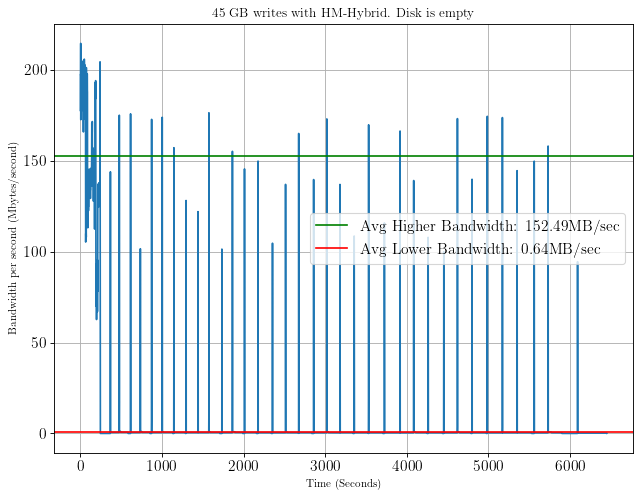

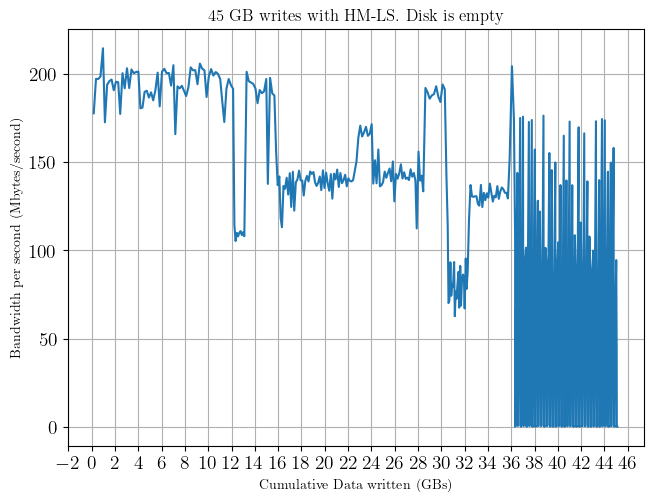

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/Empty.147Zones/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Disk is empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/2493101547.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019 19784.45283019 19784.45283019
 19784.45283019 19784.45283019]' has dtype incompa

<bound method NDFrame.describe of       index  data_written_bytes  cumulative_gb
0         0          174.117673       0.170037
1         1          195.362219       0.360820
2         2          198.110928       0.554288
3         3          200.680333       0.750265
4         4          214.287402       0.959530
...     ...                 ...            ...
6187   6187            0.054698      45.095577
6188   6188            0.035521      45.095612
6189   6189            0.027303      45.095638
6190   6190            0.019804      45.095658
6191   6191            0.005351      45.095663

[6192 rows x 3 columns]>
Average1: 2
Average2: 160


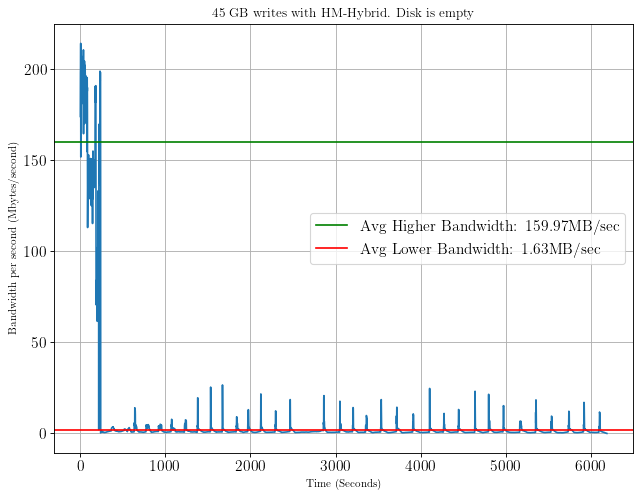

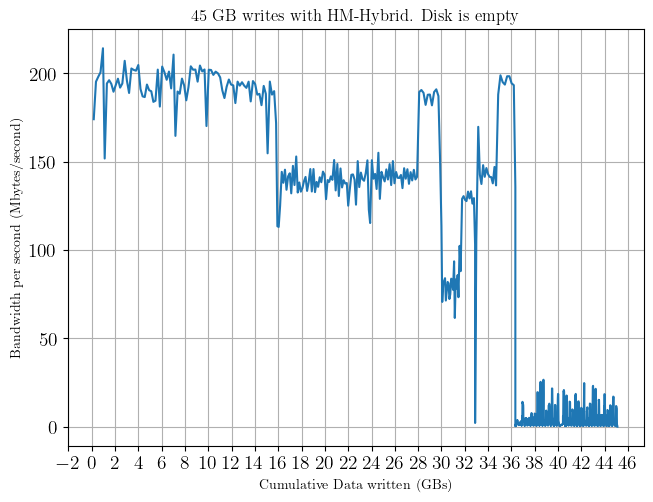

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/Empty.147Zones.WakeCount/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/6812358.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.84444444
 11650.84444444 11650.84444444 11650.84444444 11650.8

<bound method NDFrame.describe of       index  data_written_bytes  cumulative_gb
0         0          177.920622       0.173751
1         1          195.719787       0.364883
2         2          194.295190       0.554625
3         3          198.554871       0.748526
4         4          206.593662       0.950277
...     ...                 ...            ...
6072   6072            0.045541      45.094144
6073   6073            0.036311      45.094180
6074   6074            0.035159      45.094214
6075   6075            0.024055      45.094237
6076   6076            0.011003      45.094248

[6077 rows x 3 columns]>
Average1: 2
Average2: 158


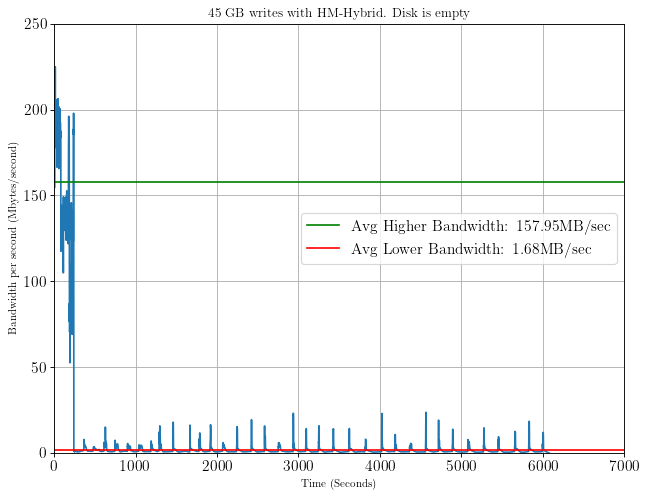

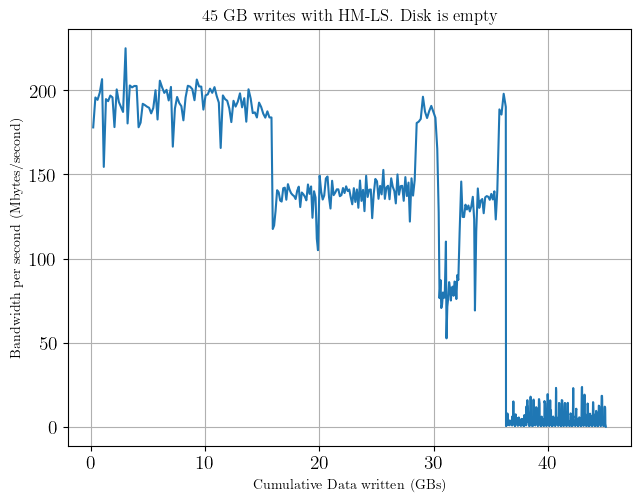

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/Empty.147Zones.WakeOne/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 7000)
plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
#ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Disk is empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/1538454268.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.82857143
 7489.82857143 7489.82857143 7489.82857143 7489.82857143 7489.

<bound method NDFrame.describe of       index  data_written_bytes  cumulative_gb
0         0           73.062843       0.071350
1         1          122.204369       0.190691
2         2          191.436990       0.377641
3         3           94.559456       0.469984
4         4          124.821634       0.591880
...     ...                 ...            ...
6958   6958            0.315068      45.093275
6959   6959            0.258841      45.093528
6960   6960            0.136685      45.093662
6961   6961            0.136685      45.093795
6962   6962            0.099527      45.093892

[6963 rows x 3 columns]>
Average1: 1
Average2: 156


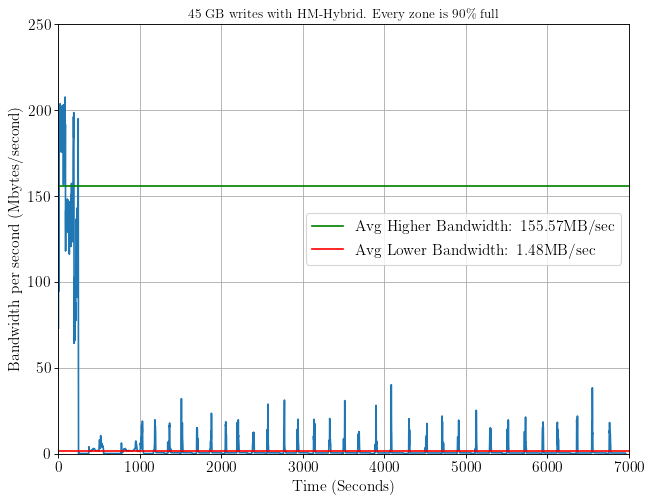

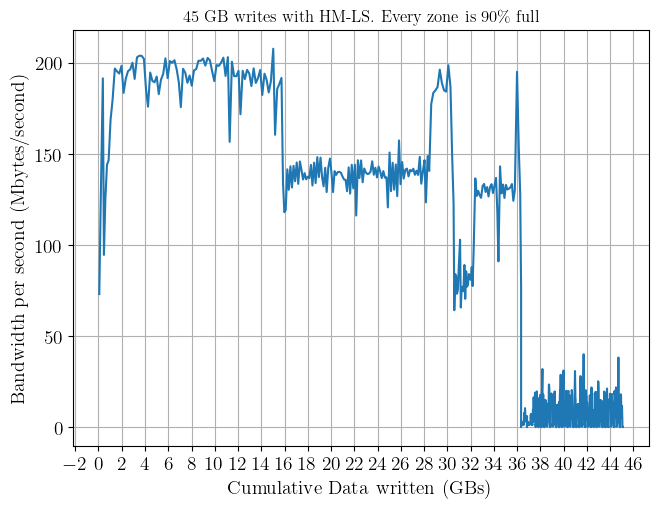

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 7000)
plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)', fontsize=14)
plt.ylabel('Bandwidth per second (Mbytes/second)', fontsize=14)
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Every zone is 90\% full")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/90Util_HMHybrid_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)', fontsize=14)
plt.ylabel('Bandwidth per second (Mbytes/second)', fontsize=14)
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Every zone is 90\% full")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/90Util_HMHybrid_cgbw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/2346785960.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.00645161
 6765.00645161 6765.00645161 6765.00645161 6765.00645161 6765.

<bound method NDFrame.describe of       index  data_written_bytes  cumulative_gb
0         0           94.464176       0.092250
1         1          216.679979       0.303852
2         2          194.548666       0.493841
3         3          199.075735       0.688251
4         4          198.888542       0.882478
...     ...                 ...            ...
9735   9735            0.035491      45.093854
9736   9736            0.035491      45.093888
9737   9737            0.035491      45.093923
9738   9738            0.032698      45.093955
9739   9739            0.000344      45.093955

[9740 rows x 3 columns]>
Average1: 1
Average2: 155


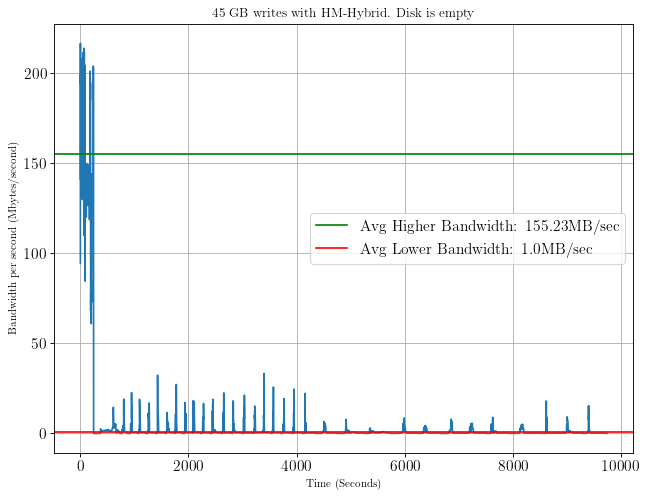

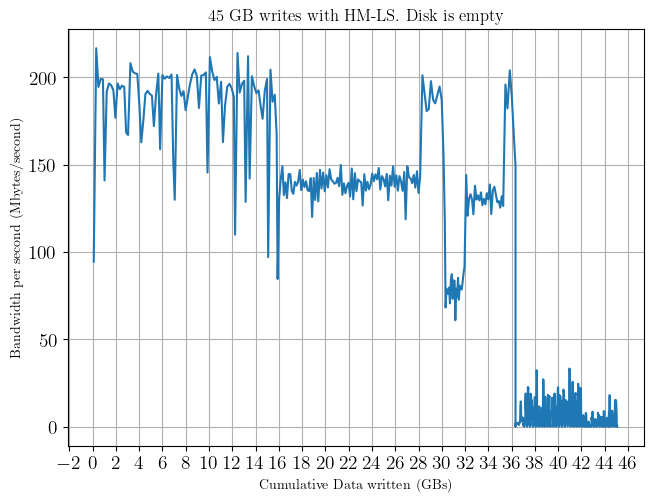

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/empty/1MB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/Empty.147Zones.WakeAfterThree/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Disk is empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/2091829546.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549
 20560.31372549 20560.31372549 20560.31372549 20560.31372549]' has dtype incompatible with int64, please explic

<bound method NDFrame.describe of        index  data_written_bytes  cumulative_gb
0          0          128.766395       0.125748
1          1          145.044411       0.267393
2          2          139.933221       0.404047
3          3          144.403305       0.545066
4          4          155.304932       0.696731
...      ...                 ...            ...
10617  10617            0.000192      45.176156
10618  10618            0.000192      45.176157
10619  10619            0.000192      45.176157
10620  10620            0.000192      45.176157
10621  10621            0.000047      45.176157

[10622 rows x 3 columns]>
Average1: 1
Average2: 147


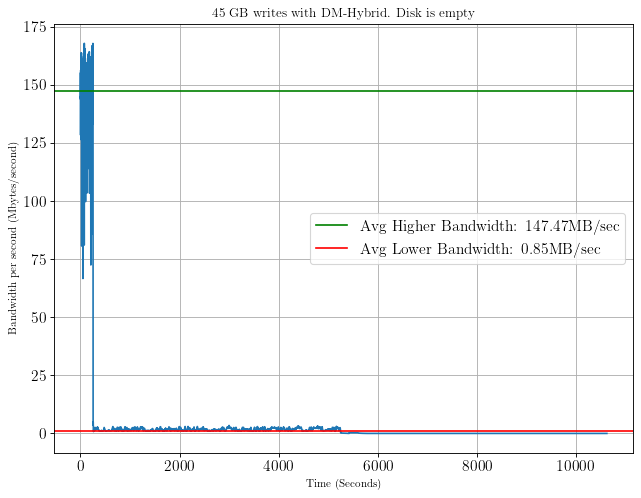

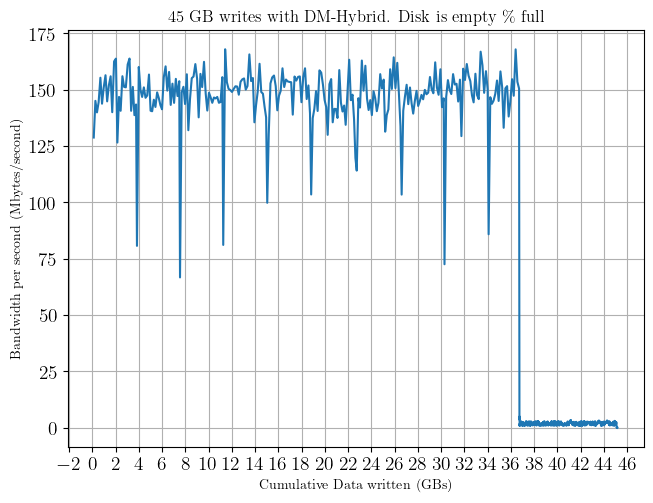

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/empty/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with DM-Hybrid. Disk is empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/empty_time_bw.png', bbox_inches='tight')
plt.show()
############
fig, ax = plt.subplots()
ax.xaxis.set_major_locator(tkr.MultipleLocator(2))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with DM-Hybrid. Disk is empty \% full")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/empty_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/2113946706.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 1028

<bound method NDFrame.describe of      index  data_written_bytes  cumulative_gb
0        0           70.315065       0.068667
1        1           92.681075       0.159176
2        2           95.522047       0.252459
3        3           80.623455       0.331193
4        4          102.121730       0.430921
..     ...                 ...            ...
748    748           56.356776      44.959417
749    749            3.902355      44.963228
750    750           68.064932      45.029698
751    751           29.173823      45.058188
752    752            2.984991      45.061103

[753 rows x 3 columns]>
Average1: 41
Average2: 90


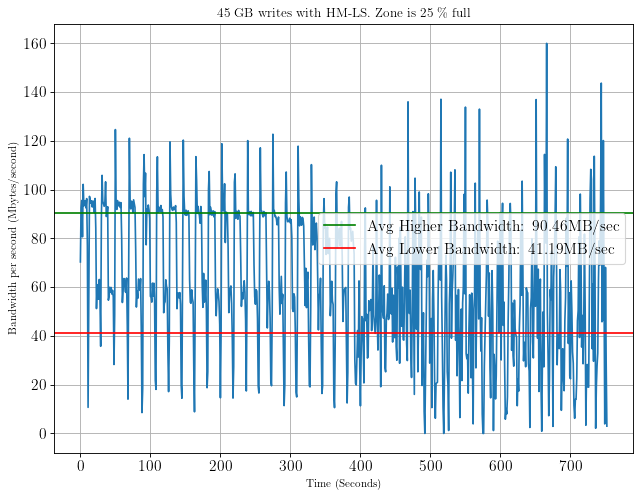

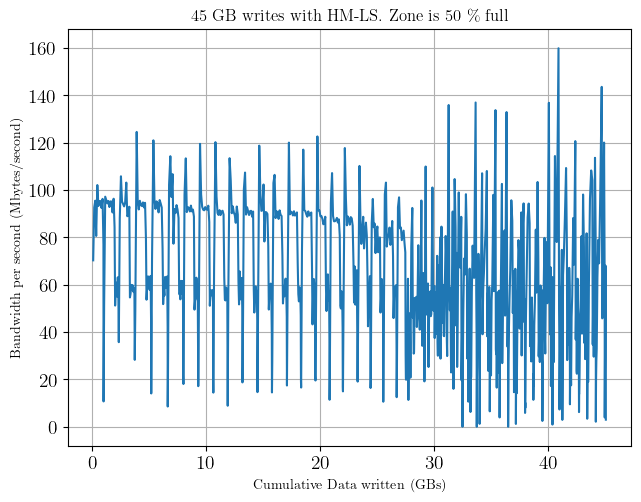

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/lsdm-util/25Util/1MB/8TB/90-10-LBA/45GB/rtm-round2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 25 \% full")
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/25Util_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 50 \% full")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/25Util_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/3130083849.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 14979.65714286
 14979.65714286 14979.65714286 14979.65714286 1497

<bound method NDFrame.describe of      index  data_written_bytes  cumulative_gb
0        0          153.723807       0.150121
1        1          187.817868       0.333537
2        2          191.300853       0.520354
3        3          202.469117       0.718078
4        4          183.593992       0.897369
..     ...                 ...            ...
519    519          117.308188      44.898328
520    520           84.432624      44.980782
521    521           36.387148      45.016317
522    522           77.389850      45.091893
523    523           13.293471      45.104874

[524 rows x 3 columns]>
Average1: 55
Average2: 185


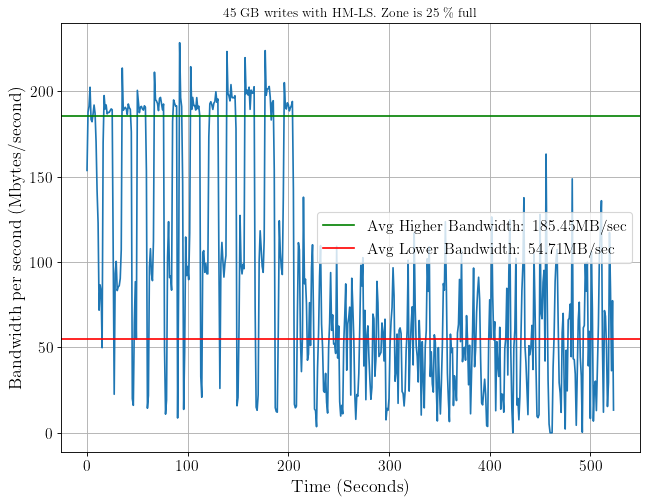

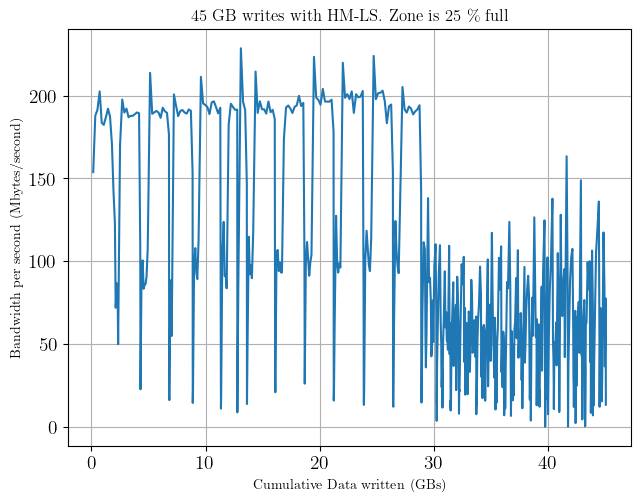

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/lsdm-util/25Util/1MB/8TB/90-10-LBA/45GB/lowerLBAS/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
#ax.set_xlim(0, 8000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)', fontsize=16)
plt.ylabel('Bandwidth per second (Mbytes/second)', fontsize=16)
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 25 \% full")
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/25Util_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 25 \% full")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/25Util_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/1371731780.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2
 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2 13107.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[submission_time:completion_time] += write_rate_per_ms


<bound method NDFrame.describe of      index  data_written_bytes  cumulative_gb
0        0          155.954437       0.152299
1        1          182.086679       0.330118
2        2          191.170694       0.516808
3        3          203.973422       0.716001
4        4          189.855837       0.901407
..     ...                 ...            ...
645    645           68.950384      44.998923
646    646           24.066306      45.022425
647    647           32.678723      45.054338
648    648           27.247740      45.080947
649    649            5.475026      45.086294

[650 rows x 3 columns]>
Average1: 47
Average2: 186


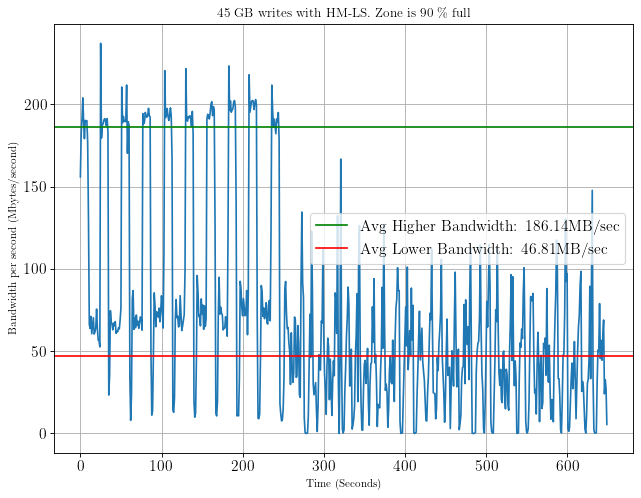

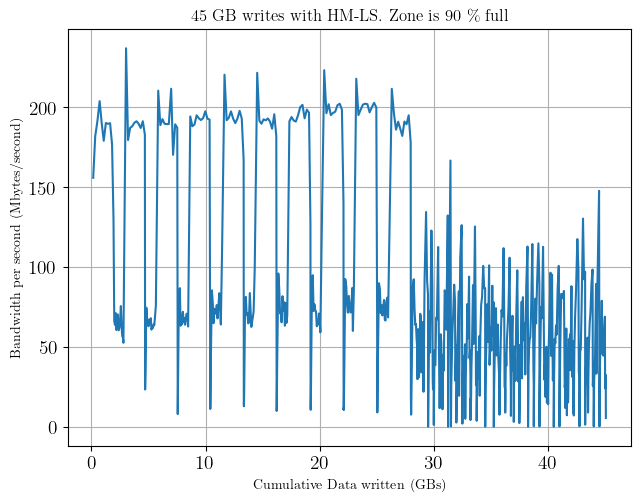

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/lsdm-util/90Util/1MB/8TB/90-10-LBA/45GB/round2/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 90 \% full")
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/90Util_new_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Zone is 90 \% full")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/LSDM/90Util_new_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/1278196042.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.83941606
 7653.83941606 7653.83941606 7653.83941606 7653.83941606 7653.

<bound method NDFrame.describe of      index  data_written_bytes  cumulative_gb
0        0          162.822887       0.159007
1        1          200.767723       0.355069
2        2          184.113320       0.534867
3        3          198.377415       0.728595
4        4          188.136858       0.912322
..     ...                 ...            ...
946    946            2.146587      45.114176
947    947            2.146587      45.116272
948    948            2.146587      45.118369
949    949            2.146587      45.120465
950    950            1.368452      45.121801

[951 rows x 3 columns]>
Average1: 9
Average2: 157


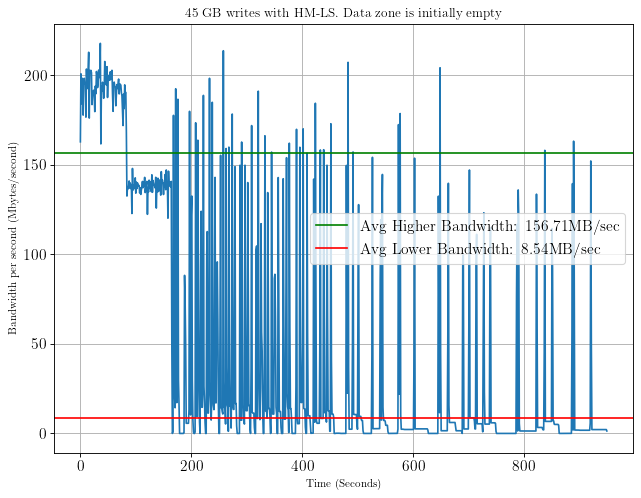

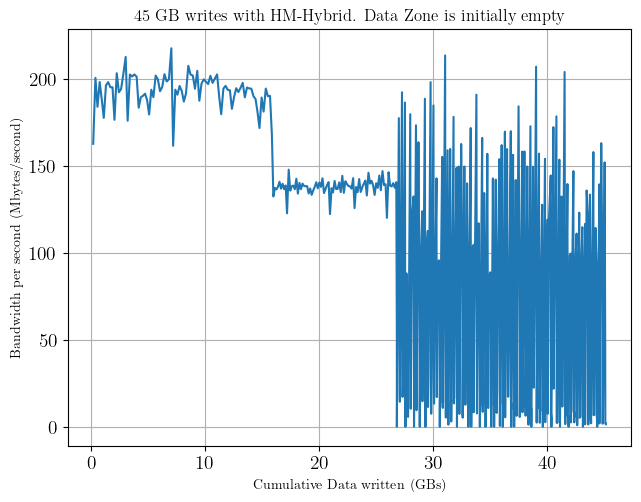

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/worst_case/HM-Hybrid/90Util/1MB/8TB/90-10-LBA/45GB/test/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Data zone is initially empty")
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/Empty_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Data Zone is initially empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/Empty_new_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


/tmp/ipykernel_28218/3676111629.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478 22795.13043478
 22795.13043478 22795.13043478 22795.13043478]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[submission_time

<bound method NDFrame.describe of      index  data_written_bytes  cumulative_gb
0        0           55.097487       0.053806
1        1           30.063938       0.083165
2        2           81.505620       0.162761
3        3           90.842507       0.251474
4        4           81.820136       0.331377
..     ...                 ...            ...
411    411            0.174243      29.056145
412    412            0.100005      29.056243
413    413            0.100005      29.056341
414    414            0.100005      29.056438
415    415            0.042602      29.056480

[416 rows x 3 columns]>
Average1: 7
Average2: 124


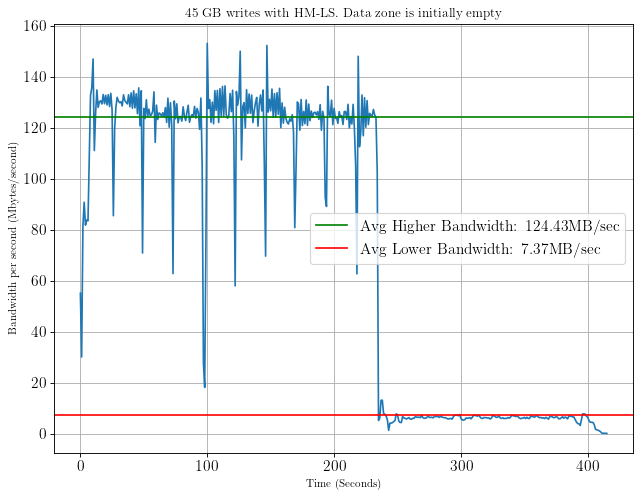

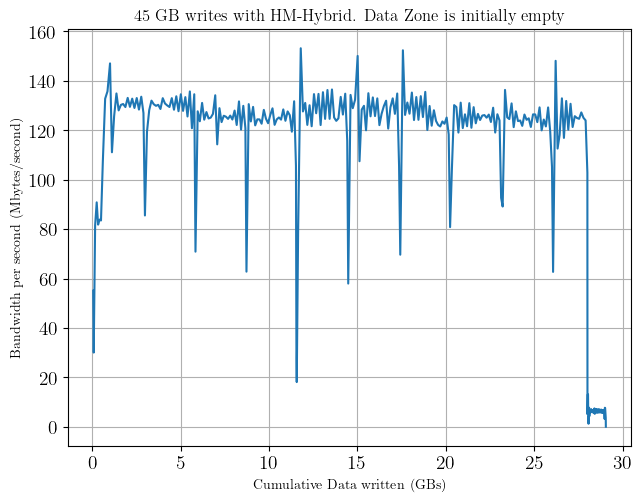

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/STL/1M/uniform-random/90Util/run1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = df['duration']/1000000 #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = math.ceil(df['completion_time'].max())

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-LS. Data zone is initially empty")
#plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/Empty_time_bw.png', bbox_inches='tight')
plt.show()
############
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
plt.xlabel('Cumulative Data written (GBs)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("45 GB writes with HM-Hybrid. Data Zone is initially empty")    
plt.savefig('/home/surbhi/github/surbhi-plots/new/HM-Hybrid/Empty_new_cg_bw.png', bbox_inches='tight')
plt.show()
    

######################################################3333


    


In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1024
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

dfs = []
# Step 1: Read the CSV file into a Pandas DataFrame
dfl = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/lowerLBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dfl)
dftwo = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/2000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dftwo)
dfthree = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/3000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dfthree)
dfmiddle = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/middleLBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dfmiddle)
dffourPoint = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/4500-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dffourPoint)
dffive = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/5000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dffive)
dffivePoint = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/5500-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dffivePoint)
dfSix = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/6000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dfSix)
dfhigh = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/higherLBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfs.append(dfhigh)

df_grouped_arr = []
avg_higher_bw_arr = []

dfl = pd.DataFrame()
for i in range(9):
    dfl = dfs[i]
    dfl['submission_time'] = dfl['submission_time'] - dfl.iloc[0].submission_time
    dfl['duration'] = dfl['duration']/(10 ** 6) #convert ns to ms
    dfl['completion_time'] = dfl['submission_time'] + dfl['duration']

    # Step 3: Determine the start and end time of the entire test
    start_time = dfl['submission_time'].min()
    end_time = math.ceil(dfl[-1]['completion_time']) + 1

    # Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
    data_written_msl = pd.DataFrame(index=range(start_time, end_time+1, 1), columns=['data_written_bytes'])
    data_written_msl['data_written_bytes'] = 0
    start = 0
    end = 0
    for index, row in df.iterrows():
        duration = row['duration']
        start = int(row['submission_time'])
        end = start+math.floor(duration)
    
        payload = 1048576
        write_rate_per_ms = payload / max(duration, 1.)
        assert(write_rate_per_ms <= payload)
        residue = payload - write_rate_per_ms * math.floor(duration)
        assert (payload >= (write_rate_per_ms * math.floor(duration)))
        data_written_msl.loc[start:end-1] += write_rate_per_ms
        # residue could be zero when last == end                    
        #data_written_msl.loc[end] += residue

    print ("End: " + str(end) + "end_time: " + str(end_time) + "index: " + str(index))
    print(index)
    data_written_msl.reset_index(drop=True, inplace=True)
    last_non_zero_index = data_written_msl[data_written_msl.ne(0).any(axis=1)].index[-1]
    data_written_msl = data_written_msl.loc[:last_non_zero_index]
    df_grouped = data_written_msl.groupby(custom_grouping).sum()
    # Reset the index to make it a regular column
    df_grouped.reset_index(inplace=True)
    df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
    df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
    
    df_grouped_arr.append(df_grouped)
    
    data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
    kmeans = KMeans(n_clusters=2)
    kmeans.fit(data_array)
    # Get the cluster centers
    cluster_centers = kmeans.cluster_centers_.flatten()
    # Sort cluster centers to get the lowest and highest modes
    cluster_centers.sort()
    # Calculate the average of each mode
    average_mode1 = cluster_centers[0]
    average_mode2 = cluster_centers[1]

    avg_higher_bw_arr.append(average_mode2)

plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.ylim(0, 225)
myyticks = range(0, 230, 10)
plt.xticks(fontsize=14)
plt.yticks(ticks=myyticks, fontsize=14)
plt.tight_layout()
plt.grid(True)  # Optionally, add grid lines
plt.xlabel('Time (Seconds)', fontsize=16)
plt.ylabel('Bandwidth per second (Mbytes/second)', fontsize=16)


df_grouped = df_grouped_arr[0]
average_mode2 = avg_higher_bw_arr[0]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="lower LBA, offset = 17GB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)


df_grouped = df_grouped_arr[1]
average_mode2 = avg_higher_bw_arr[1]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 2TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[2]
average_mode2 = avg_higher_bw_arr[2]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 3TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[3]
average_mode2 = avg_higher_bw_arr[3]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 4TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[4]
average_mode2 = avg_higher_bw_arr[4]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 4.5TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[5]
average_mode2 = avg_higher_bw_arr[5]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 5TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[6]
average_mode2 = avg_higher_bw_arr[6]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 5.5TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

df_grouped = df_grouped_arr[7]
average_mode2 = avg_higher_bw_arr[7]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="offset = 6TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)


df_grouped = df_grouped_arr[8]
average_mode2 = avg_higher_bw_arr[8]   
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
plt.plot(df_grouped.index, df_grouped['data_written_bytes'], label="higher LBA, offset = 7TB")
#plt.axhline(y=average_mode2, linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)

plt.legend(loc='upper right', fontsize=14)
plt.title("10 GB sequential writes to the disk, no translation layer involved", fontsize=16)
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/seq_writes_bw_time.png', bbox_inches='tight')
plt.show()
###################################################### 


NameError: name 'pd' is not defined

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
dfl = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/2000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfl['submission_time'] = dfl['submission_time'] - dfl.iloc[0].submission_time
dfl['duration'] = round(dfl['duration']/1000000, ) #convert ns to ms
dfl['completion_time'] = dfl['submission_time'] + dfl['duration']


# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
dfl['submission_time'] = pd.to_datetime(dfl['submission_time'], unit='ms')
dfl['completion_time'] = pd.to_datetime(dfl['completion_time'], unit='ms')
#print(df)]

# Step 3: Determine the start and end time of the entire test
start_time = dfl['submission_time'].min()
end_time = dfl['completion_time'].max()

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
time_index_ms = pd.date_range(start=start_time, end=end_time, freq='ms')
data_written_msl = pd.DataFrame(index=time_index_ms, columns=['data_written_bytes'])
data_written_msl['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in dfl.iterrows():
    submission_time = row['submission_time']
    completion_time = row['completion_time']
    write_size_bytes = 1048576  # 4K in bytes
    duration_ms = row['duration']
    write_rate_per_ms = write_size_bytes / duration_ms
    data_written_msl.loc[submission_time:completion_time] += write_rate_per_ms

# Reset the index to convert the time index to a regular integer index
data_written_msl.reset_index(drop=True, inplace=True)
df_grouped = data_written_msl.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("10 GB sequential writes to offset=2000 on disk (offset=17GB), no translation layer involved")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/seq_writes_2000LBA_bw_time.png', bbox_inches='tight')
plt.show()
######################################################3333


    


FileNotFoundError: [Errno 2] No such file or directory: '/home/surbhi/measurements/STL/sequentialWrites/1MB/2000-LBA/lat_log_avg_lat.1.log'

/tmp/ipykernel_6339/2723583414.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280.15686275
 10280.15686275 10280.15686275 10280.15686275 10280

<bound method NDFrame.describe of     index  data_written_bytes  cumulative_gb
0       0          132.742993       0.129632
1       1          159.721386       0.285610
2       2          166.356848       0.448068
3       3          161.372261       0.605658
4       4          160.840365       0.762728
..    ...                 ...            ...
59     59          163.780347       9.533787
60     60          168.297249       9.698140
61     61          164.018271       9.858314
62     62          148.652176      10.003482
63     63           23.118126      10.026058

[64 rows x 3 columns]>
Average1: 23
Average2: 163


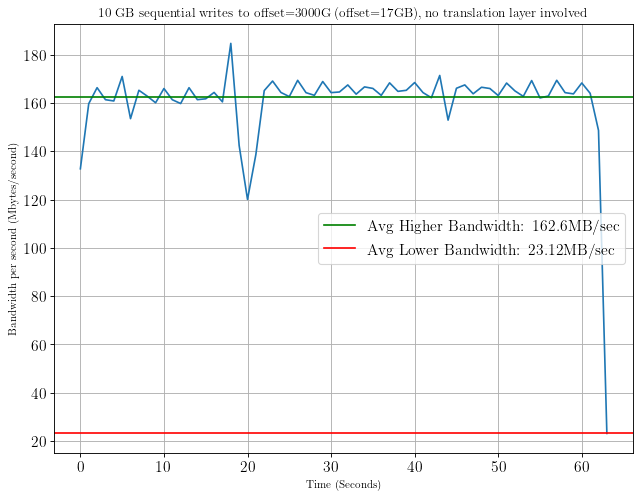

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
dfl = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/1MB/3000-LBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
dfl['submission_time'] = dfl['submission_time'] - dfl.iloc[0].submission_time
dfl['duration'] = round(dfl['duration']/1000000, ) #convert ns to ms
dfl['completion_time'] = dfl['submission_time'] + dfl['duration']


# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
dfl['submission_time'] = pd.to_datetime(dfl['submission_time'], unit='ms')
dfl['completion_time'] = pd.to_datetime(dfl['completion_time'], unit='ms')
#print(df)]

# Step 3: Determine the start and end time of the entire test
start_time = dfl['submission_time'].min()
end_time = dfl['completion_time'].max()

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
time_index_ms = pd.date_range(start=start_time, end=end_time, freq='ms')
data_written_msl = pd.DataFrame(index=time_index_ms, columns=['data_written_bytes'])
data_written_msl['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in dfl.iterrows():
    submission_time = row['submission_time']
    completion_time = row['completion_time']
    write_size_bytes = 1048576  # 4K in bytes
    duration_ms = row['duration']
    write_rate_per_ms = write_size_bytes / duration_ms
    data_written_msl.loc[submission_time:completion_time] += write_rate_per_ms

# Reset the index to convert the time index to a regular integer index
data_written_msl.reset_index(drop=True, inplace=True)
df_grouped = data_written_msl.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("10 GB sequential writes to offset=3000G (offset=17GB), no translation layer involved")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/seq_writes_3000GB_bw_time.png', bbox_inches='tight')
plt.show()
######################################################3333


    


/tmp/ipykernel_6339/3337535645.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.77570093
 9799.77570093 9799.77570093 9799.77570093 9799.77570093 9799.7

<bound method NDFrame.describe of     index  data_written_bytes  cumulative_gb
0       0          118.758113       0.115975
1       1          147.559882       0.260076
2       2          151.064972       0.407601
3       3          146.409486       0.550579
4       4          152.219741       0.699231
..    ...                 ...            ...
65     65          146.293737       9.560720
66     66          150.471079       9.707664
67     67          147.964214       9.852161
68     68          134.771623       9.983773
69     69           40.865364      10.023681

[70 rows x 3 columns]>
Average1: 41
Average2: 148


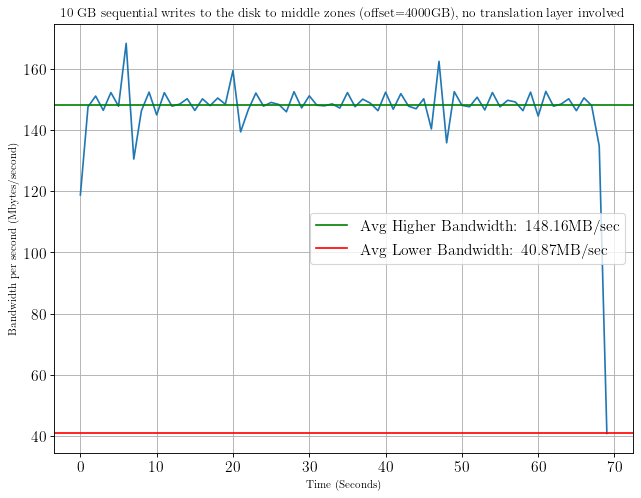

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/middleLBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = round(df['duration']/1000000, ) #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']


# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
df['submission_time'] = pd.to_datetime(df['submission_time'], unit='ms')
df['completion_time'] = pd.to_datetime(df['completion_time'], unit='ms')
#print(df)]

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = df['completion_time'].max()

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
time_index_ms = pd.date_range(start=start_time, end=end_time, freq='ms')
data_written_ms = pd.DataFrame(index=time_index_ms, columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    submission_time = row['submission_time']
    completion_time = row['completion_time']
    write_size_bytes = 1048576  # 4K in bytes
    duration_ms = row['duration']
    write_rate_per_ms = write_size_bytes / duration_ms
    data_written_ms.loc[submission_time:completion_time] += write_rate_per_ms

# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("10 GB sequential writes to the disk to middle zones (offset=4000GB), no translation layer involved")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/seq_writes_middleLBA_bw_time.png', bbox_inches='tight')
plt.show()
######################################################3333


    


/tmp/ipykernel_6339/405761904.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75757576
 7943.75757576 7943.75757576 7943.75757576 7943.75757576 7943.75

<bound method NDFrame.describe of     index  data_written_bytes  cumulative_gb
0       0           75.190666       0.073428
1       1          108.961775       0.179836
2       2          106.402556       0.283745
3       3          108.702117       0.389900
4       4          105.343049       0.492774
..    ...                 ...            ...
94     94          103.246862       9.716849
95     95          100.245881       9.814745
96     96          104.120693       9.916426
97     97           83.101920       9.997580
98     98           19.614278      10.016734

[99 rows x 3 columns]>
Average1: 20
Average2: 104


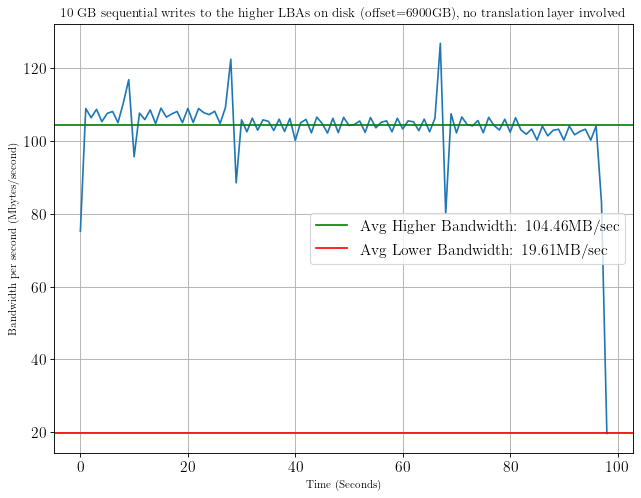

In [ ]:
# Define a custom grouping function
def custom_grouping(index):
    return index // 1000
    
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']
# do not change the dir order. The cumulative gb df has lesser rows for 25Util - as it writes faster. 
# the number of rows created for the df depends on the first col
dirs = ["90Util", "50Util", "25Util"]
#runs = ["run2", "run1"]

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv('/home/surbhi/measurements/STL/sequentialWrites/higherLBA/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = df['submission_time'] - df.iloc[0].submission_time
df['duration'] = round(df['duration']/1000000, ) #convert ns to ms
df['completion_time'] = df['submission_time'] + df['duration']


# Step 2: Convert submission time and completion time columns to datetime objects with unit as milliseconds
df['submission_time'] = pd.to_datetime(df['submission_time'], unit='ms')
df['completion_time'] = pd.to_datetime(df['completion_time'], unit='ms')
#print(df)]

# Step 3: Determine the start and end time of the entire test
start_time = df['submission_time'].min()
end_time = df['completion_time'].max()

# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
time_index_ms = pd.date_range(start=start_time, end=end_time, freq='ms')
data_written_ms = pd.DataFrame(index=time_index_ms, columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    submission_time = row['submission_time']
    completion_time = row['completion_time']
    write_size_bytes = 1048576  # 4K in bytes
    duration_ms = row['duration']
    write_rate_per_ms = write_size_bytes / duration_ms
    data_written_ms.loc[submission_time:completion_time] += write_rate_per_ms

# Reset the index to convert the time index to a regular integer index
data_written_ms.reset_index(drop=True, inplace=True)
df_grouped = data_written_ms.groupby(custom_grouping).sum()
# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2)
print(df_grouped.describe)

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
#fig, ax = plt.subplots()
# Plot the data size over time for each resolution
#fig, ax = plt.subplots()
#ax.set_xlim(0, 8000)
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
myxticks = range(0, 8000, 20)
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.tight_layout()
plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
plt.xlabel('Time (Seconds)')
plt.ylabel('Bandwidth per second (Mbytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("10 GB sequential writes to the higher LBAs on disk (offset=6900GB), no translation layer involved")
plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/seq_writes_higherLBA_bw_time.png', bbox_inches='tight')
plt.show()
######################################################3333


    
